In [ ]:
from pathlib import Path
import pyarrow.parquet as pq
import pyarrow as pa
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


total = 0
folder = Path("../Data/Goodreads_Books/genres_top100")
for f in folder.glob("*.parquet"):
    size = os.path.getsize(f)
    total += size
    print(f"{f.name}: {size / 1e6:.1f} MB")
print(f"Total: {total / 1e6:.1f} MB")

action.parquet: 4.6 MB
adult.parquet: 19.4 MB
adventure.parquet: 13.6 MB
amazon.parquet: 6.0 MB
american_history.parquet: 5.1 MB
animals.parquet: 9.1 MB
anthologies.parquet: 6.8 MB
art.parquet: 15.2 MB
audiobook.parquet: 39.5 MB
bdsm.parquet: 5.3 MB
biography.parquet: 25.0 MB
biography_memoir.parquet: 6.7 MB
book_club.parquet: 7.6 MB
british_literature.parquet: 7.1 MB
business.parquet: 9.7 MB
chick_lit.parquet: 8.4 MB
childrens.parquet: 33.9 MB
christian.parquet: 13.5 MB
christianity.parquet: 5.7 MB
christian_fiction.parquet: 5.2 MB
christmas.parquet: 4.6 MB
classics.parquet: 15.9 MB
comics.parquet: 25.8 MB
comic_book.parquet: 4.5 MB
contemporary.parquet: 41.4 MB
contemporary_romance.parquet: 20.5 MB
cookbooks.parquet: 9.5 MB
cooking.parquet: 5.8 MB
crime.parquet: 16.3 MB
drama.parquet: 5.2 MB
ebooks.parquet: 22.0 MB
economics.parquet: 5.1 MB
education.parquet: 5.6 MB
erotica.parquet: 14.2 MB
essays.parquet: 5.2 MB
family.parquet: 6.2 MB
fantasy.parquet: 56.3 MB
fiction.parquet: 122.9 

In [ ]:
folder = Path("../Data/Goodreads_Books/genres_top100")

# First: check what columns exist and drop anything you don't need
sample = pq.read_table(next(folder.glob("*.parquet")))
print(sample.column_names)

['id', 'name', 'author', 'url', 'genres', 'summary_clean', 'pub_year', 'star_rating', 'num_ratings', 'isbn_clean']


In [ ]:
folder = Path("../Data/Goodreads_Books/genres_top100")

keep_cols = ["id", "name", "author", "genres", "pub_year", "star_rating", "num_ratings", "isbn_clean"]

tables = []
for file in folder.glob("*.parquet"):
    table = pq.read_table(file, columns=keep_cols)
    genre_col = pa.array([file.stem] * table.num_rows)
    table = table.append_column("genre", genre_col)
    tables.append(table)

combined_table = pa.concat_tables(tables, promote_options="default")
pq.write_table(combined_table, "Data/Goodreads_Books/all_genres_combined.parquet")

In [6]:
sample = pq.read_table(next(folder.glob("*.parquet")), columns=["name", "genres"])
sample.to_pandas().head(10)

,name,genres
0,Sharpe's Devil,"[Historical Fiction, Fiction, Historical, War,..."
1,Blood Fever,"[Young Adult, Fiction, Adventure, Mystery, Thr..."
2,Detektiv Conan vs. Kaito Kid,"[Manga, Mystery, Komik, Indonesian Literature,..."
3,Marvel's Captain America: Sub Rosa,"[Marvel, Young Adult, Action, Superheroes]"
4,The Awakening,"[Post Apocalyptic, Action, Dystopia, Fiction, ..."
5,Last of the Breed,"[Fiction, Westerns, Adventure, Historical Fict..."
6,Terrible Tuesday,"[Thriller, Fiction, Adventure, Action]"
7,Terminal Freeze,"[Thriller, Fiction, Mystery, Horror, Science F..."
8,"Eureka Seven: Psalms of Planets, Vol. 2","[Manga, Science Fiction, Graphic Novels, Shone..."
9,Devil's Pass,"[Adventure, Young Adult, Canada, Fiction, Myst..."


In [ ]:
folder = Path("../Data/Goodreads_Books/genres_top100")
keep_cols = ["name", "genres", "pub_year", "star_rating", "num_ratings"]

tables = []
for file in folder.glob("*.parquet"):
    table = pq.read_table(file, columns=keep_cols)
    genre_col = pa.array([file.stem] * table.num_rows)
    table = table.append_column("source_genre", genre_col)  # from filename, as backup/comparison
    tables.append(table)

combined_table = pa.concat_tables(tables, promote_options="default")
df = combined_table.to_pandas()

# dtype cleanup — helps memory a lot with this many rows
df["pub_year"] = pd.to_numeric(df["pub_year"], errors="coerce", downcast="integer")
df["source_genre"] = df["source_genre"].astype("category")

In [11]:
print(df.shape)
print(df.memory_usage(deep=True).sum() / 1e6, "MB")
df.info()

(4820937, 7)
1170.582177 MB
<class 'pandas.DataFrame'>
RangeIndex: 4820937 entries, 0 to 4820936
Data columns (total 7 columns):
 #   Column        Dtype   
---  ------        -----   
 0   name          str     
 1   genres        object  
 2   pub_year      int16   
 3   star_rating   float64 
 4   num_ratings   int64   
 5   source_genre  category
 6   genres_list   object  
dtypes: category(1), float64(1), int16(1), int64(1), object(2), str(1)
memory usage: 344.0+ MB


In [10]:
df["genres_list"] = df["genres"].str.split(",").apply(lambda x: [g.strip() for g in x] if isinstance(x, list) else [])
exploded = df.explode("genres_list")
year_genre_counts = exploded.groupby(["pub_year", "genres_list"]).size().reset_index(name="count")

In [12]:
year_genre_counts = df.groupby(["pub_year", "source_genre"]).size().reset_index(name="count")
top_genre_per_year = year_genre_counts.loc[year_genre_counts.groupby("pub_year")["count"].idxmax()]
top_genre_per_year.sort_values("pub_year")

,pub_year,source_genre,count
20,1000,nonfiction,15
38,1001,classics,1
47,1002,classics,2
56,1004,biography,1
61,1005,comics,1
...,...,...,...
24233,3011,religion,1
24234,3017,new_adult,1
24236,3024,childrens,1
24241,3276,music,2


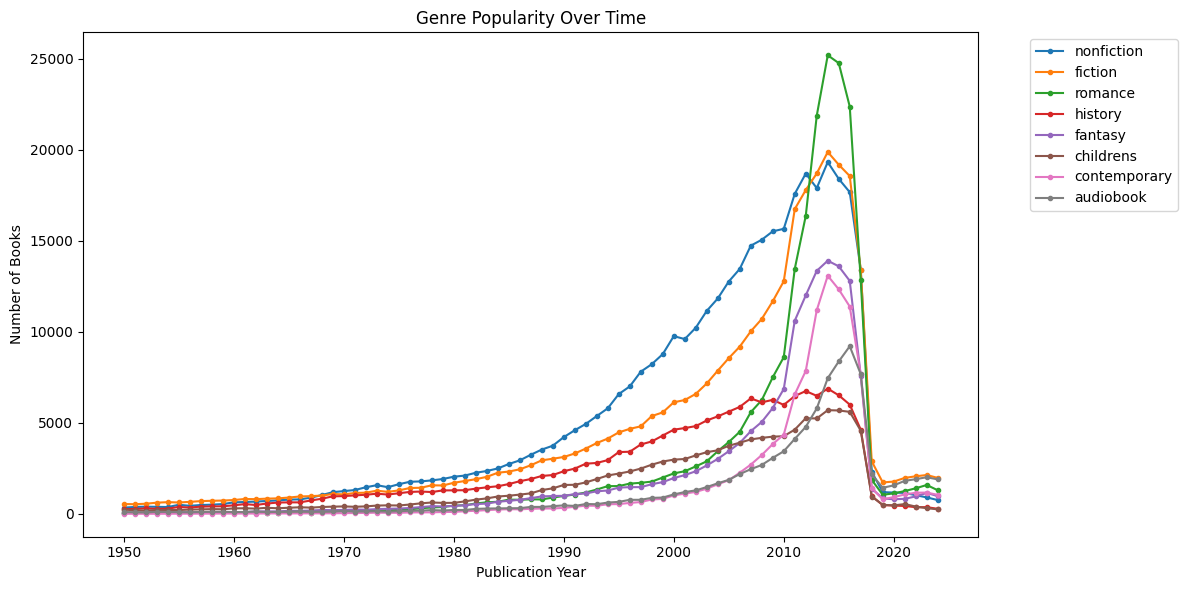

In [ ]:
# Get the overall top N genres (by total count) to keep the chart readable
top_genres = df["source_genre"].value_counts().head(8).index

plot_data = year_genre_counts[year_genre_counts["source_genre"].isin(top_genres)]

# Filter to a reasonable year range if there's junk data at the extremes
plot_data = plot_data[(plot_data["pub_year"] >= 1950) & (plot_data["pub_year"] <= 2024)]

fig, ax = plt.subplots(figsize=(12, 6))
for genre in top_genres:
    subset = plot_data[plot_data["source_genre"] == genre].sort_values("pub_year")
    ax.plot(subset["pub_year"], subset["count"], label=genre, marker="o", markersize=3)

ax.set_xlabel("Publication Year")
ax.set_ylabel("Number of Books")
ax.set_title("Genre Popularity Over Time")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

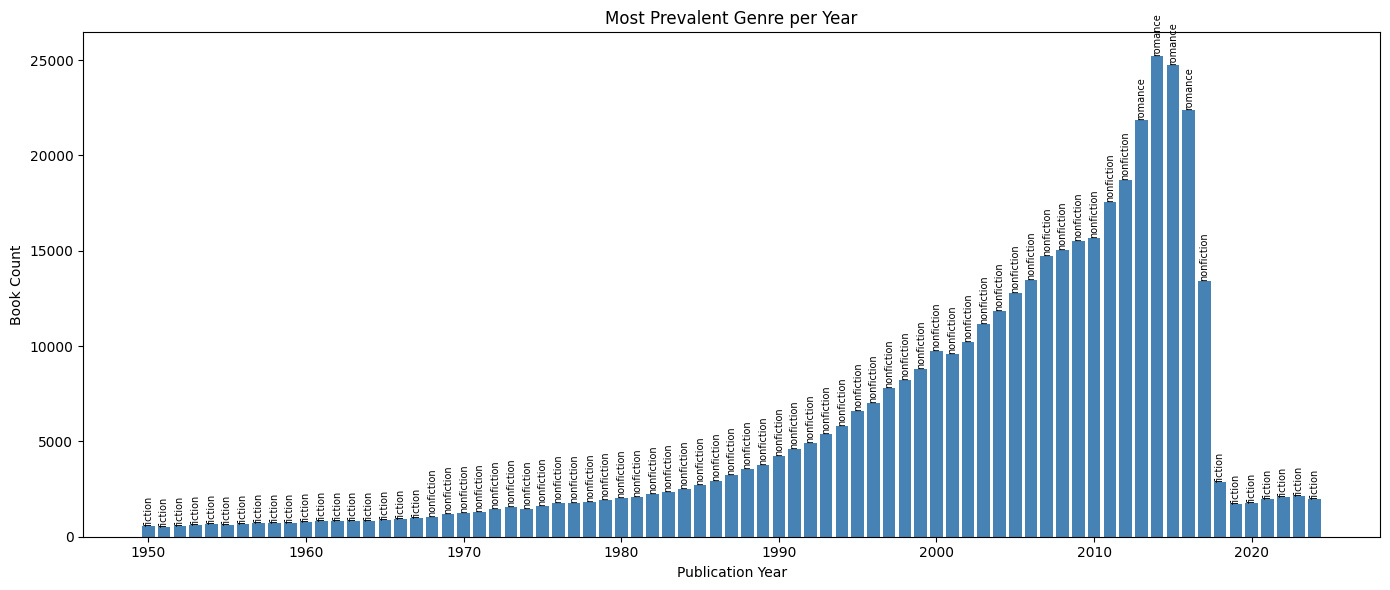

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))
subset = top_genre_per_year[(top_genre_per_year["pub_year"] >= 1950) & (top_genre_per_year["pub_year"] <= 2024)]
ax.bar(subset["pub_year"], subset["count"], color="steelblue")


for _, row in subset.iterrows():
    ax.text(row["pub_year"], row["count"], row["source_genre"], rotation=90, ha="center", va="bottom", fontsize=7)

ax.set_xlabel("Publication Year")
ax.set_ylabel("Book Count")
ax.set_title("Most Prevalent Genre per Year")
plt.tight_layout()
plt.show()

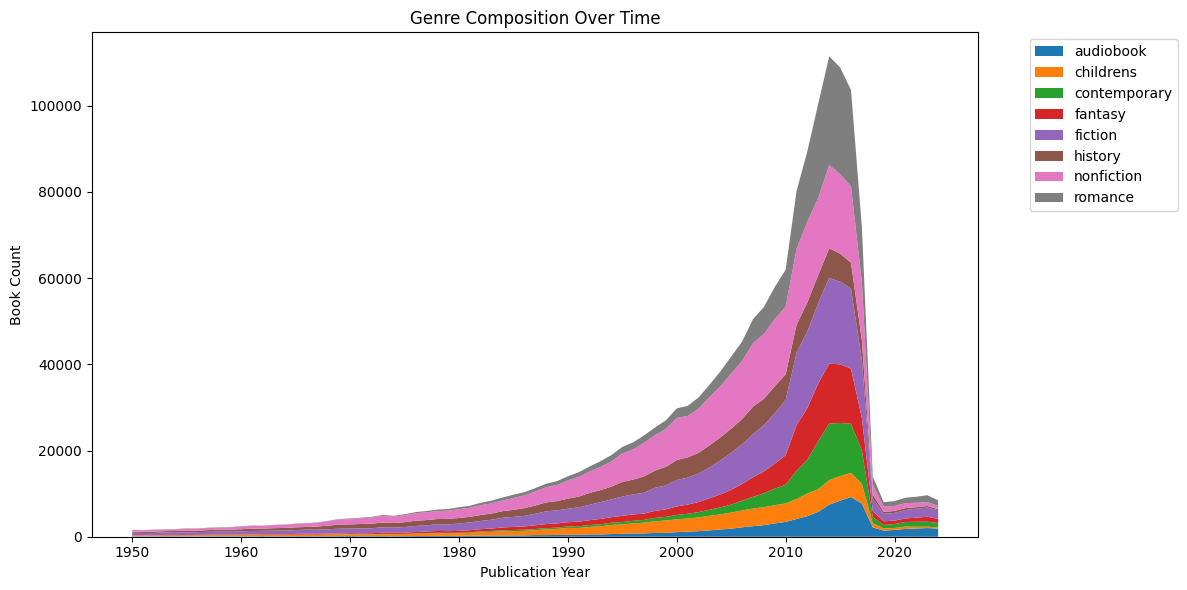

In [16]:
pivot = plot_data.pivot(index="pub_year", columns="source_genre", values="count").fillna(0)

fig, ax = plt.subplots(figsize=(12, 6))
ax.stackplot(pivot.index, pivot.T.values, labels=pivot.columns)
ax.set_xlabel("Publication Year")
ax.set_ylabel("Book Count")
ax.set_title("Genre Composition Over Time")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [17]:
df.groupby("pub_year")["num_ratings"].median().tail(15)

pub_year
2401    459.0
2523     38.0
2550     11.0
2557     25.0
2558      7.5
2559     27.0
2560     98.0
2601    103.0
2911    104.0
3001      7.0
3011      5.0
3017     24.0
3024     93.0
3276      9.0
9999      5.0
Name: num_ratings, dtype: float64

In [18]:
# Filter to realistic years
valid = df[(df["pub_year"] >= 1900) & (df["pub_year"] <= 2024)]

yearly_totals = valid["pub_year"].value_counts().sort_index()
yearly_median_ratings = valid.groupby("pub_year")["num_ratings"].median()

print(yearly_totals.tail(15))
print(yearly_median_ratings.tail(15))

pub_year
2010    182268
2011    237321
2012    267486
2013    299510
2014    327496
2015    317305
2016    294606
2017    197160
2018     36988
2019     21513
2020     21941
2021     23649
2022     24092
2023     24686
2024     21868
Name: count, dtype: int64
pub_year
2010     206.0
2011     210.0
2012     211.0
2013     225.0
2014     238.0
2015     242.0
2016     257.0
2017     334.0
2018     829.0
2019    1257.0
2020    1318.0
2021    1468.0
2022    1499.0
2023    1385.0
2024    1317.0
Name: num_ratings, dtype: float64


In [19]:
df["pub_year"].describe()
(df["pub_year"] < 1900).sum()
(df["pub_year"] > 2025).sum()

np.int64(9807)

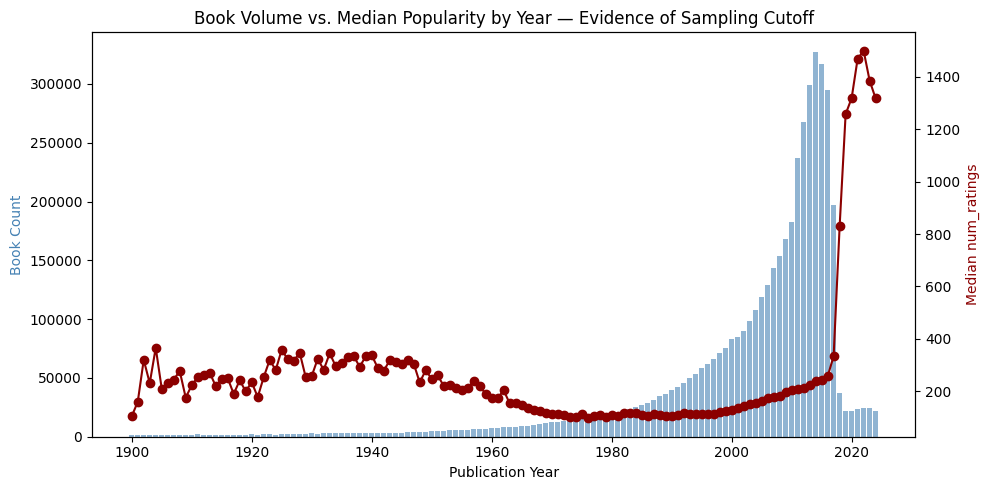

In [20]:
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(yearly_totals.index, yearly_totals.values, alpha=0.6, color="steelblue", label="Book count")
ax1.set_ylabel("Book Count", color="steelblue")

ax2 = ax1.twinx()
ax2.plot(yearly_median_ratings.index, yearly_median_ratings.values, color="darkred", marker="o", label="Median ratings")
ax2.set_ylabel("Median num_ratings", color="darkred")

ax1.set_xlabel("Publication Year")
ax1.set_title("Book Volume vs. Median Popularity by Year — Evidence of Sampling Cutoff")
plt.tight_layout()
plt.show()

In [21]:
# Filter to reliable year range
valid = df[(df["pub_year"] >= 1900) & (df["pub_year"] <= 2016)].copy()

# Pull fiction/non-fiction out as a separate category, not a genre
fiction_labels = {"fiction", "non-fiction", "nonfiction"}

valid["category"] = valid["source_genre"].apply(
    lambda g: "Fiction" if g == "fiction" else ("Non-Fiction" if g in {"non-fiction", "nonfiction"} else "Genre")
)

# Genre-only subset, excluding fiction/nonfiction from the "which genre wins" analysis
genre_only = valid[~valid["source_genre"].isin(fiction_labels)]

In [22]:
year_genre_counts = genre_only.groupby(["pub_year", "source_genre"]).size().reset_index(name="count")
top_genre_per_year = year_genre_counts.loc[year_genre_counts.groupby("pub_year")["count"].idxmax()]
top_genre_per_year.sort_values("pub_year")

,pub_year,source_genre,count
21,1900,classics,150
105,1901,classics,155
187,1902,classics,172
264,1903,classics,170
341,1904,classics,205
...,...,...,...
10117,2012,romance,16373
10215,2013,romance,21879
10313,2014,romance,25199
10411,2015,romance,24768


In [24]:
fiction_trend = valid[valid["category"].isin(["Fiction", "Non-Fiction"])].groupby(
    ["pub_year", "category"]
).size().reset_index(name="count")

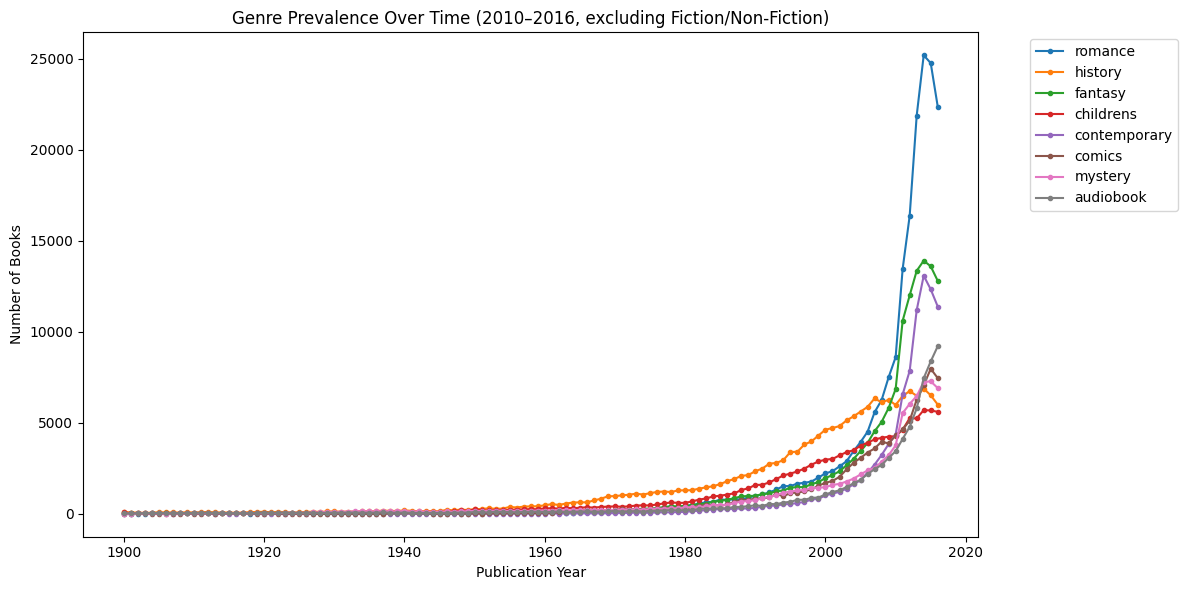

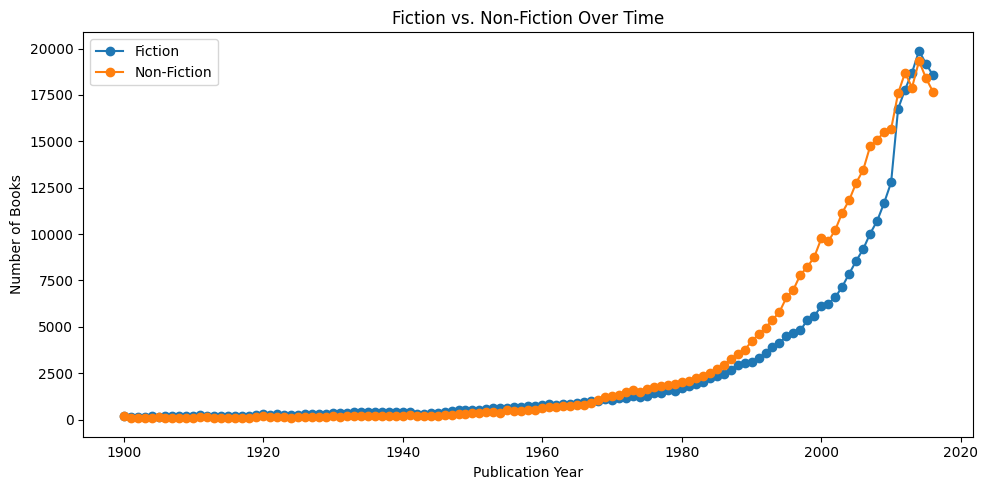

In [ ]:
# Chart 1: Top genres over time (fiction/nonfiction excluded)
top_genres = genre_only["source_genre"].value_counts().head(8).index
plot_data = year_genre_counts[year_genre_counts["source_genre"].isin(top_genres)]

fig, ax = plt.subplots(figsize=(12, 6))
for genre in top_genres:
    subset = plot_data[plot_data["source_genre"] == genre].sort_values("pub_year")
    ax.plot(subset["pub_year"], subset["count"], label=genre, marker="o", markersize=3)
ax.set_xlabel("Publication Year")
ax.set_ylabel("Number of Books")
ax.set_title("Genre Prevalence Over Time (2010–2016, excluding Fiction/Non-Fiction)")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Chart 2: Fiction vs Non-Fiction split
fig, ax = plt.subplots(figsize=(10, 5))
for cat in ["Fiction", "Non-Fiction"]:
    subset = fiction_trend[fiction_trend["category"] == cat].sort_values("pub_year")
    ax.plot(subset["pub_year"], subset["count"], label=cat, marker="o")
ax.set_xlabel("Publication Year")
ax.set_ylabel("Number of Books")
ax.set_title("Fiction vs. Non-Fiction Over Time")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Step 1: Filter to reliable years
valid = df[(df["pub_year"] >= 1900) & (df["pub_year"] <= 2016)].copy()

# Step 2: Make sure genres_list is a clean list of stripped strings
# (rebuild it here in case it wasn't preserved correctly earlier)
valid["genres_list"] = valid["genres"].apply(
    lambda g: [x.strip() for x in g] if isinstance(g, (list, tuple)) else []
)

# Step 3: Explode so each row is one (book, genre) pair
exploded = valid.explode("genres_list")
exploded = exploded[exploded["genres_list"].notna() & (exploded["genres_list"] != "")]

# Step 4: Normalize casing so "Fiction" / "fiction" / "FICTION" aren't counted separately
exploded["genres_list"] = exploded["genres_list"].str.strip().str.lower()

# Step 5: Split fiction/non-fiction out as a category, not a genre
fiction_labels = {"fiction", "non-fiction", "nonfiction"}
genre_only = exploded[~exploded["genres_list"].isin(fiction_labels)]

# Step 6: Genre prevalence per year (now using the FULL genre list, not just filename)
year_genre_counts = genre_only.groupby(["pub_year", "genres_list"]).size().reset_index(name="count")
top_genre_per_year = year_genre_counts.loc[year_genre_counts.groupby("pub_year")["count"].idxmax()]

# Step 7: Fiction vs non-fiction trend, based on tags present anywhere in genres_list
exploded["category"] = exploded["genres_list"].apply(
    lambda g: "Fiction" if g == "fiction" else ("Non-Fiction" if g in {"non-fiction", "nonfiction"} else None)
)
fiction_trend = exploded[exploded["category"].notna()].groupby(
    ["pub_year", "category"]
).size().reset_index(name="count")

print(top_genre_per_year.sort_values("pub_year"))
print(fiction_trend)

Empty DataFrame
Columns: [pub_year, genres_list, count]
Index: []
Empty DataFrame
Columns: [pub_year, category, count]
Index: []


In [27]:
print(type(valid["genres"].iloc[0]))
print(valid["genres"].iloc[0])

<class 'numpy.ndarray'>
['Historical Fiction' 'Fiction' 'Historical' 'War' 'Adventure'
 'Military Fiction' 'Audiobook' 'Action' 'Ebooks' '19th Century']


In [ ]:


valid["genres_list"] = valid["genres"].apply(
    lambda g: [str(x).strip() for x in g] if isinstance(g, (list, tuple, np.ndarray)) else []
)

# Sanity check before continuing
print(valid["genres_list"].head(10))
print((valid["genres_list"].str.len() > 0).sum(), "rows with non-empty genre lists")

0    [Historical Fiction, Fiction, Historical, War,...
1    [Young Adult, Fiction, Adventure, Mystery, Thr...
2    [Manga, Mystery, Komik, Indonesian Literature,...
3           [Marvel, Young Adult, Action, Superheroes]
4    [Post Apocalyptic, Action, Dystopia, Fiction, ...
5    [Fiction, Westerns, Adventure, Historical Fict...
6               [Thriller, Fiction, Adventure, Action]
7    [Thriller, Fiction, Mystery, Horror, Science F...
8    [Manga, Science Fiction, Graphic Novels, Shone...
9    [Adventure, Young Adult, Canada, Fiction, Myst...
Name: genres_list, dtype: object
4352106 rows with non-empty genre lists


In [29]:
# Step 3: Explode so each row is one (book, genre) pair
exploded = valid.explode("genres_list")
exploded = exploded[exploded["genres_list"].notna() & (exploded["genres_list"] != "")]

# Step 4: Normalize casing so "Fiction" / "fiction" / "FICTION" aren't counted separately
exploded["genres_list"] = exploded["genres_list"].str.strip().str.lower()

# Step 5: Split fiction/non-fiction out as a category, not a genre
fiction_labels = {"fiction", "non-fiction", "nonfiction"}
genre_only = exploded[~exploded["genres_list"].isin(fiction_labels)]

# Step 6: Genre prevalence per year (using the FULL genre list)
year_genre_counts = genre_only.groupby(["pub_year", "genres_list"]).size().reset_index(name="count")
top_genre_per_year = year_genre_counts.loc[year_genre_counts.groupby("pub_year")["count"].idxmax()]

# Step 7: Fiction vs non-fiction trend
exploded["category"] = exploded["genres_list"].apply(
    lambda g: "Fiction" if g == "fiction" else ("Non-Fiction" if g in {"non-fiction", "nonfiction"} else None)
)
fiction_trend = exploded[exploded["category"].notna()].groupby(
    ["pub_year", "category"]
).size().reset_index(name="count")

print(top_genre_per_year.sort_values("pub_year"))
print(fiction_trend)

       pub_year genres_list   count
70         1900    classics     703
388        1901    classics     759
639        1902    classics     929
889        1903    classics     832
1127       1904    classics    1123
...         ...         ...     ...
64717      2012     romance   91455
65880      2013     romance  117083
67030      2014     romance  127908
68204      2015     romance  120988
69349      2016     romance  107475

[117 rows x 3 columns]
     pub_year     category   count
0        1900      Fiction     664
1        1900  Non-Fiction     669
2        1901      Fiction     621
3        1901  Non-Fiction     347
4        1902      Fiction     813
..        ...          ...     ...
229      2014  Non-Fiction   59650
230      2015      Fiction  107758
231      2015  Non-Fiction   57517
232      2016      Fiction  103859
233      2016  Non-Fiction   55787

[234 rows x 3 columns]


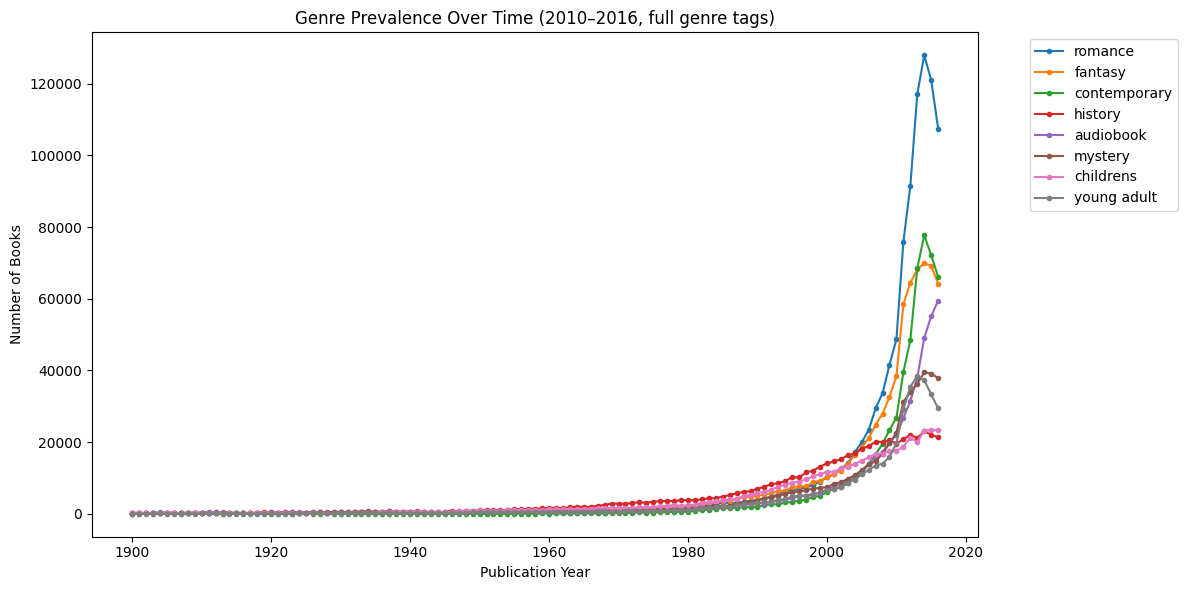

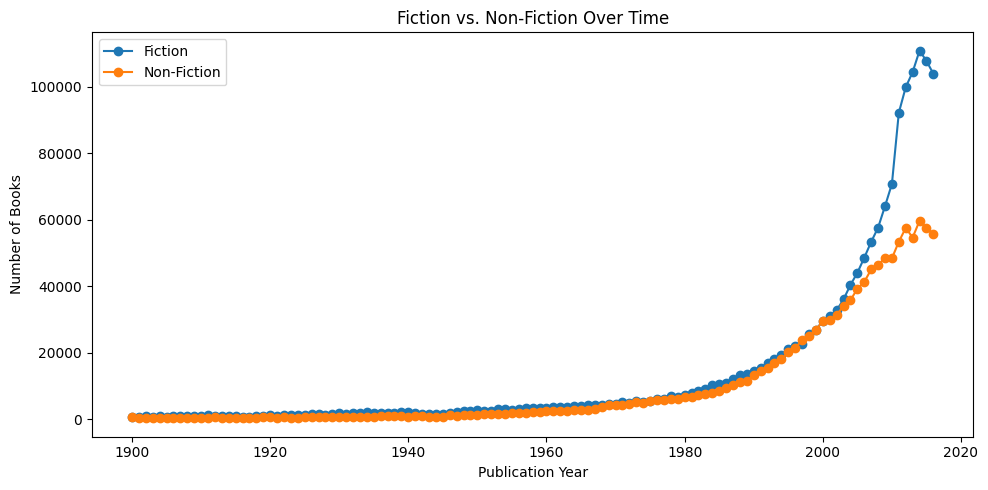

In [ ]:
# Chart 1: Top genres over time (excluding fiction/nonfiction)
top_genres = genre_only["genres_list"].value_counts().head(8).index
plot_data = year_genre_counts[year_genre_counts["genres_list"].isin(top_genres)]

fig, ax = plt.subplots(figsize=(12, 6))
for genre in top_genres:
    subset = plot_data[plot_data["genres_list"] == genre].sort_values("pub_year")
    ax.plot(subset["pub_year"], subset["count"], label=genre, marker="o", markersize=3)
ax.set_xlabel("Publication Year")
ax.set_ylabel("Number of Books")
ax.set_title("Genre Prevalence Over Time (2010–2016, full genre tags)")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Chart 2: Fiction vs Non-Fiction split
fig, ax = plt.subplots(figsize=(10, 5))
for cat in ["Fiction", "Non-Fiction"]:
    subset = fiction_trend[fiction_trend["category"] == cat].sort_values("pub_year")
    ax.plot(subset["pub_year"], subset["count"], label=cat, marker="o")
ax.set_xlabel("Publication Year")
ax.set_ylabel("Number of Books")
ax.set_title("Fiction vs. Non-Fiction Over Time")
ax.legend()
plt.tight_layout()
plt.show()

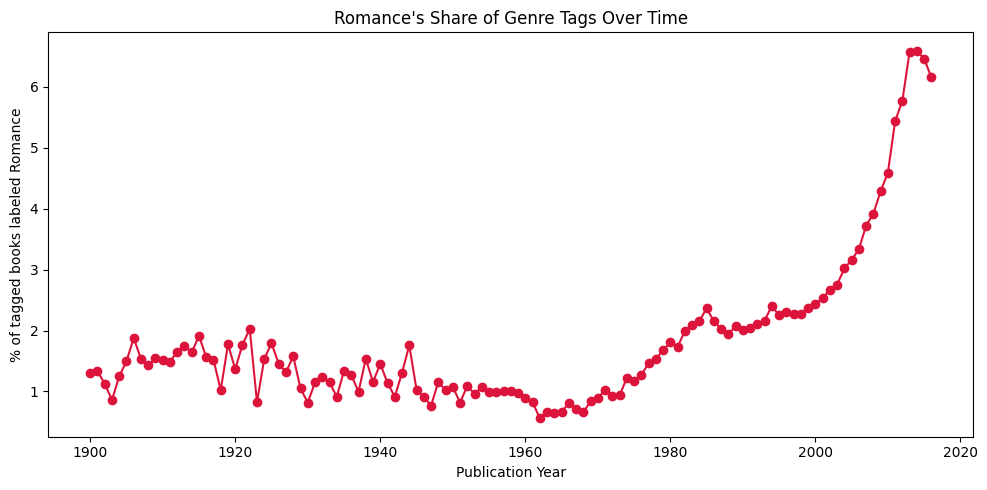

In [31]:
yearly_totals = genre_only.groupby("pub_year")["genres_list"].count()
romance_by_year = genre_only[genre_only["genres_list"] == "romance"].groupby("pub_year").size()
romance_share = (romance_by_year / yearly_totals * 100).dropna()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(romance_share.index, romance_share.values, marker="o", color="crimson")
ax.set_xlabel("Publication Year")
ax.set_ylabel("% of tagged books labeled Romance")
ax.set_title("Romance's Share of Genre Tags Over Time")
plt.tight_layout()
plt.show()

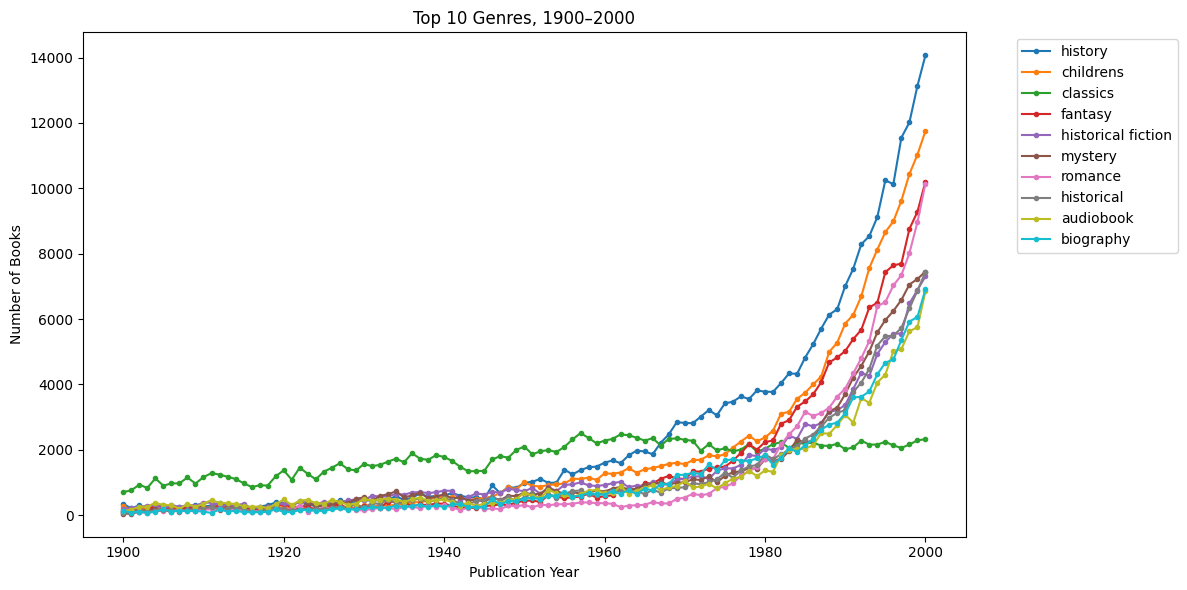

In [ ]:
# Filter to 1900-2000 specifically
early = genre_only[(genre_only["pub_year"] >= 1900) & (genre_only["pub_year"] <= 2000)]

# Get top 10 genres WITHIN this range (not from the full dataset)
top_genres_early = early["genres_list"].value_counts().head(10).index

early_year_counts = early.groupby(["pub_year", "genres_list"]).size().reset_index(name="count")
plot_data_early = early_year_counts[early_year_counts["genres_list"].isin(top_genres_early)]

fig, ax = plt.subplots(figsize=(12, 6))
for genre in top_genres_early:
    subset = plot_data_early[plot_data_early["genres_list"] == genre].sort_values("pub_year")
    ax.plot(subset["pub_year"], subset["count"], label=genre, marker="o", markersize=3)

ax.set_xlabel("Publication Year")
ax.set_ylabel("Number of Books")
ax.set_title("Top 10 Genres, 1900–2000")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [33]:
early["pub_year"].value_counts().sort_index().head(30)

pub_year
1900     8557
1901     6911
1902     8595
1903     7210
1904    10188
1905     8748
1906     8905
1907     8849
1908     9733
1909     8862
1910    10767
1911    12020
1912    11006
1913    10542
1914     9565
1915     8639
1916     7990
1917     8022
1918     8500
1919    11272
1920    13778
1921     9833
1922    14006
1923    12889
1924    11150
1925    13008
1926    14735
1927    15774
1928    14038
1929    14947
Name: count, dtype: int64

In [34]:
early_unique_books = valid[(valid["pub_year"] >= 1900) & (valid["pub_year"] <= 1929)]
print(early_unique_books["name"].nunique())
print(early_unique_books.groupby("pub_year")["name"].nunique())

15306
pub_year
1900    712
1901    383
1902    384
1903    369
1904    409
1905    444
1906    401
1907    432
1908    436
1909    459
1910    506
1911    522
1912    501
1913    482
1914    448
1915    398
1916    426
1917    464
1918    445
1919    537
1920    736
1921    545
1922    640
1923    559
1924    533
1925    567
1926    629
1927    663
1928    658
1929    721
Name: name, dtype: int64


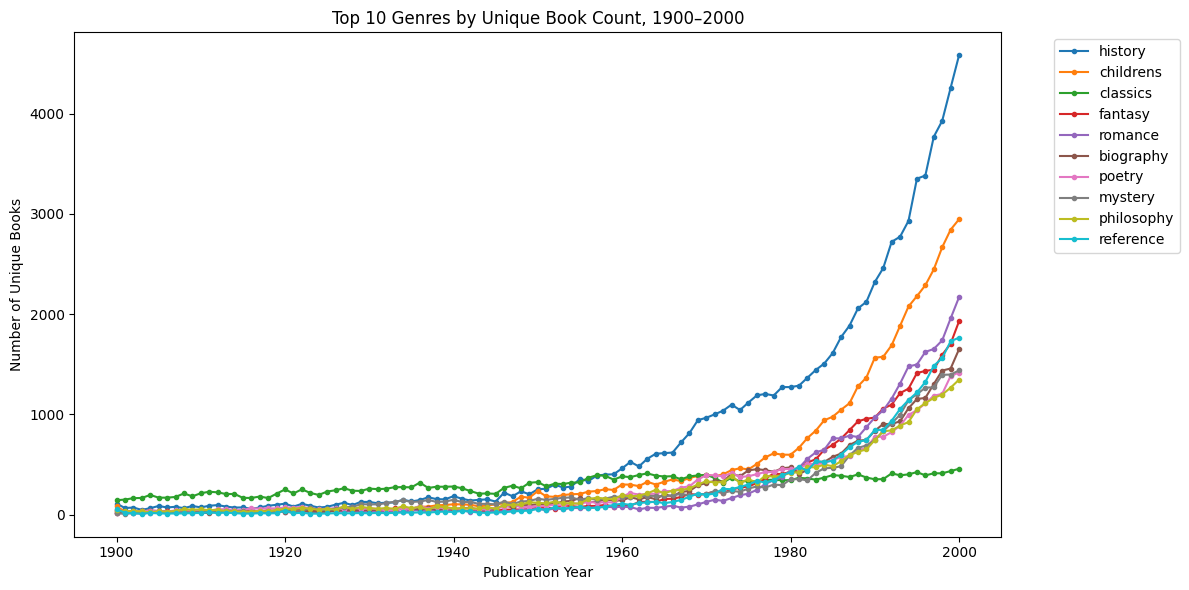

In [35]:
# Count unique books per genre per year, not genre-tag rows
unique_genre_counts = early.groupby(["pub_year", "genres_list"])["name"].nunique().reset_index(name="book_count")

top_genres_by_books = unique_genre_counts.groupby("genres_list")["book_count"].sum().sort_values(ascending=False).head(10).index

plot_data_unique = unique_genre_counts[unique_genre_counts["genres_list"].isin(top_genres_by_books)]

fig, ax = plt.subplots(figsize=(12, 6))
for genre in top_genres_by_books:
    subset = plot_data_unique[plot_data_unique["genres_list"] == genre].sort_values("pub_year")
    ax.plot(subset["pub_year"], subset["book_count"], label=genre, marker="o", markersize=3)

ax.set_xlabel("Publication Year")
ax.set_ylabel("Number of Unique Books")
ax.set_title("Top 10 Genres by Unique Book Count, 1900–2000")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

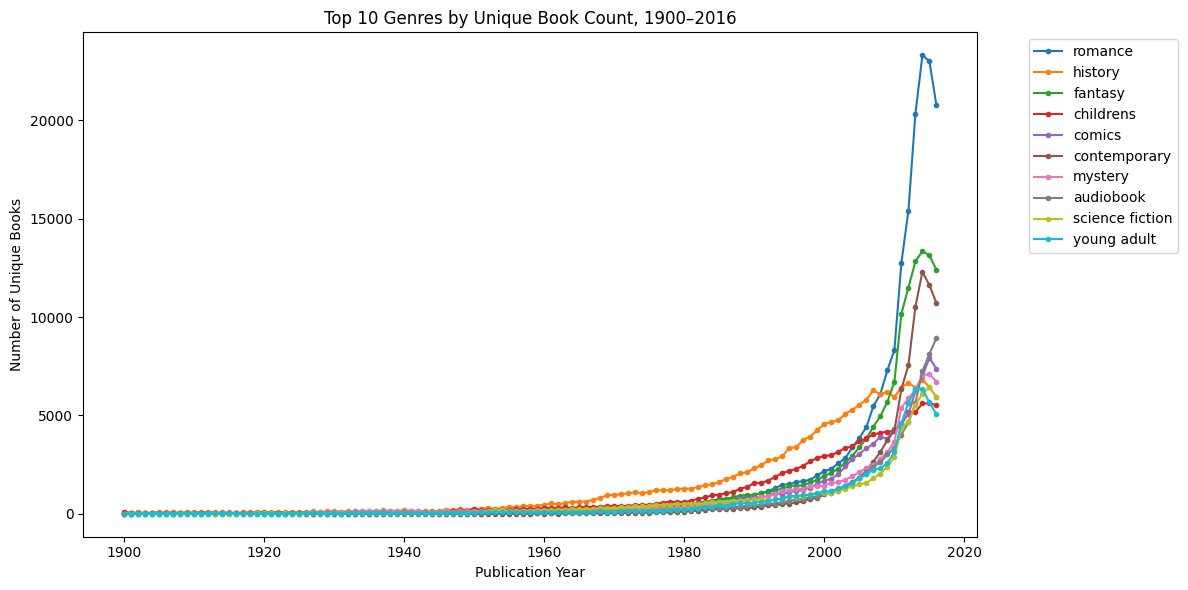

In [ ]:
# --- Full range 1900-2016, unique book counts per genre per year ---
year_genre_counts = genre_only.groupby(["pub_year", "genres_list"])["name"].nunique().reset_index(name="book_count")

# Most prevalent genre per year, by unique books
top_genre_per_year = year_genre_counts.loc[year_genre_counts.groupby("pub_year")["book_count"].idxmax()]

# Top 10 genres overall (by total unique books, summed across years)
top_genres = year_genre_counts.groupby("genres_list")["book_count"].sum().sort_values(ascending=False).head(10).index

plot_data = year_genre_counts[year_genre_counts["genres_list"].isin(top_genres)]

fig, ax = plt.subplots(figsize=(12, 6))
for genre in top_genres:
    subset = plot_data[plot_data["genres_list"] == genre].sort_values("pub_year")
    ax.plot(subset["pub_year"], subset["book_count"], label=genre, marker="o", markersize=3)
ax.set_xlabel("Publication Year")
ax.set_ylabel("Number of Unique Books")
ax.set_title("Top 10 Genres by Unique Book Count, 1900–2016")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

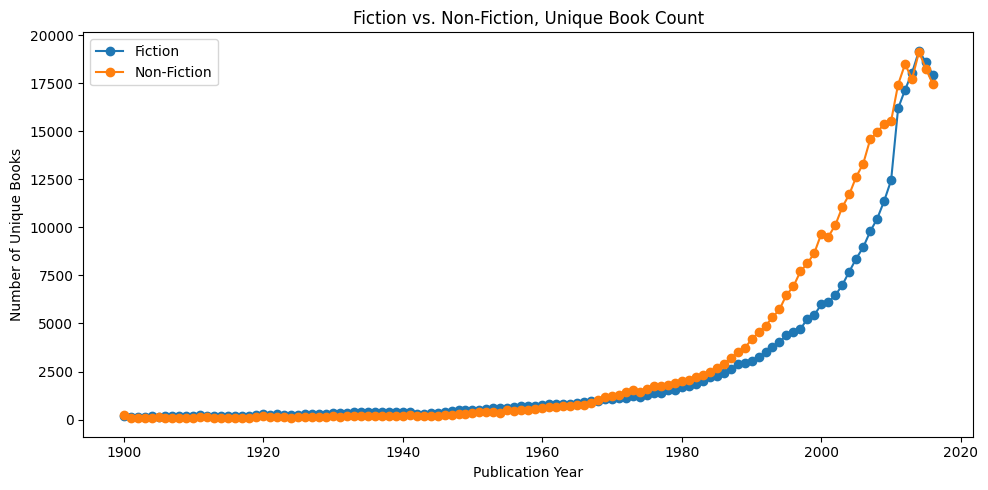

In [37]:
fiction_trend = exploded[exploded["category"].notna()].groupby(
    ["pub_year", "category"]
)["name"].nunique().reset_index(name="book_count")

fig, ax = plt.subplots(figsize=(10, 5))
for cat in ["Fiction", "Non-Fiction"]:
    subset = fiction_trend[fiction_trend["category"] == cat].sort_values("pub_year")
    ax.plot(subset["pub_year"], subset["book_count"], label=cat, marker="o")
ax.set_xlabel("Publication Year")
ax.set_ylabel("Number of Unique Books")
ax.set_title("Fiction vs. Non-Fiction, Unique Book Count")
ax.legend()
plt.tight_layout()
plt.show()

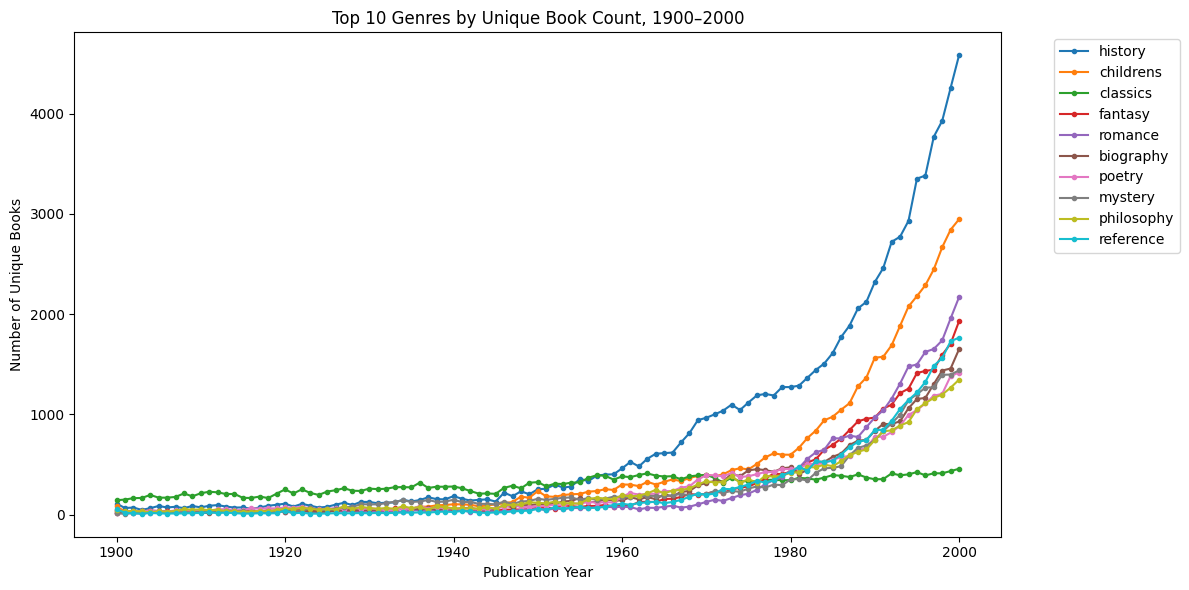

In [38]:
early = genre_only[(genre_only["pub_year"] >= 1900) & (genre_only["pub_year"] <= 2000)]
early_unique_counts = early.groupby(["pub_year", "genres_list"])["name"].nunique().reset_index(name="book_count")
top_genres_early = early_unique_counts.groupby("genres_list")["book_count"].sum().sort_values(ascending=False).head(10).index

plot_data_early = early_unique_counts[early_unique_counts["genres_list"].isin(top_genres_early)]

fig, ax = plt.subplots(figsize=(12, 6))
for genre in top_genres_early:
    subset = plot_data_early[plot_data_early["genres_list"] == genre].sort_values("pub_year")
    ax.plot(subset["pub_year"], subset["book_count"], label=genre, marker="o", markersize=3)
ax.set_xlabel("Publication Year")
ax.set_ylabel("Number of Unique Books")
ax.set_title("Top 10 Genres by Unique Book Count, 1900–2000")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [40]:
# Look at a sample of books tagged "history" to see if the label is being applied broadly
sample_history = early[early["genres_list"] == "history"]["name"].drop_duplicates().sample(15, random_state=1)
print(sample_history.tolist())

['Understanding the I Ching', 'Class Struggles in Tanzania', 'Rome, Britain and the Anglo Saxons', 'Le Roi-Soleil se lève aussi', 'Twelve Doors to Japan', 'STRANGE SECTS AND CURIOUS CULTS [BAALISM - SHIVISM - VOODOOISM - THE PENITENTES', 'Colonial Wars of North America, 1512-1763: An Encyclopedia', 'A Zone of Engagement', 'Sphinx 2. Geheimnisse der Geschichte. Von Marco Polo bis Rasputin.', 'Coming to England', 'The Desert Air War', 'A Thread of Years', 'Fiasco: The Break-out of the German Battleships', 'Ted Poston: Pioneer American Journalist', 'Instant Cities: Urbanization and the Rise of San Francisco and Denver']


In [41]:
history_books = early[early["genres_list"] == "history"]
history_ids = history_books["name"].unique()
co_tags = early[early["name"].isin(history_ids) & (early["genres_list"] != "history")]
co_tags["genres_list"].value_counts().head(15)

genres_list
biography           71619
politics            47422
philosophy          34579
religion            28814
american history    27898
memoir              26674
historical          26563
war                 22746
biography memoir    22545
reference           21474
classics            18966
science             18085
art                 15514
military fiction    15063
sociology           14404
Name: count, dtype: int64

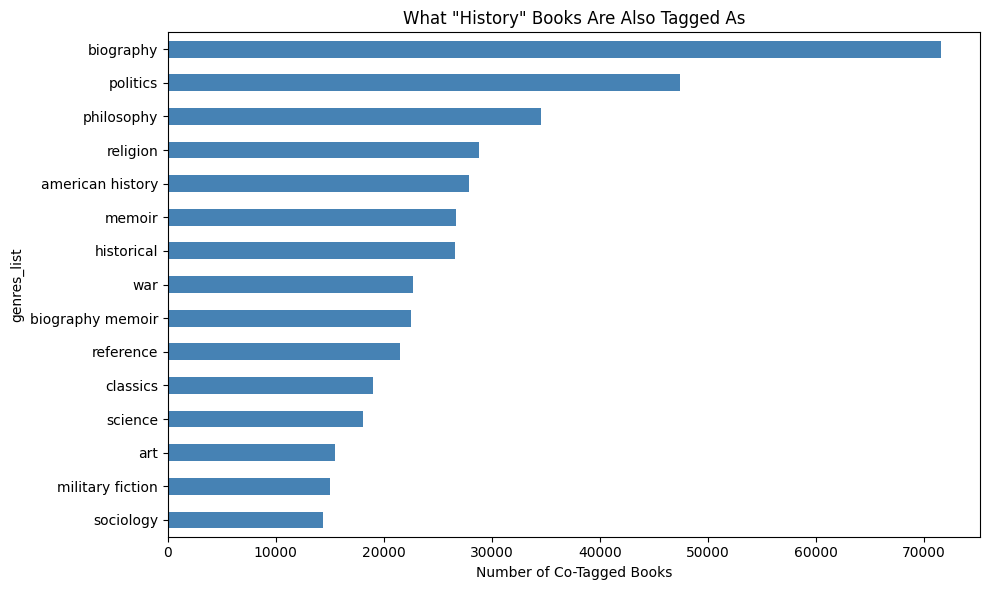

In [ ]:
co_tags_top15 = co_tags["genres_list"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6))
co_tags_top15.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Number of Co-Tagged Books")
ax.set_title("What \"History\" Books Are Also Tagged As")
plt.tight_layout()
plt.show()

In [44]:
romance_books = early[early["genres_list"] == "romance"]
romance_ids = romance_books["name"].unique()
co_tags_romance = early[early["name"].isin(romance_ids) & (early["genres_list"] != "romance")]
co_tags_romance["genres_list"].value_counts().head(15)

genres_list
historical fiction      45887
historical              45672
historical romance      35501
contemporary            29412
contemporary romance    22466
fantasy                 20348
classics                19570
audiobook               19448
mystery                 18848
novels                  18262
adult                   17791
young adult             17120
harlequin               14962
chick lit               13043
ebooks                  12743
Name: count, dtype: int64

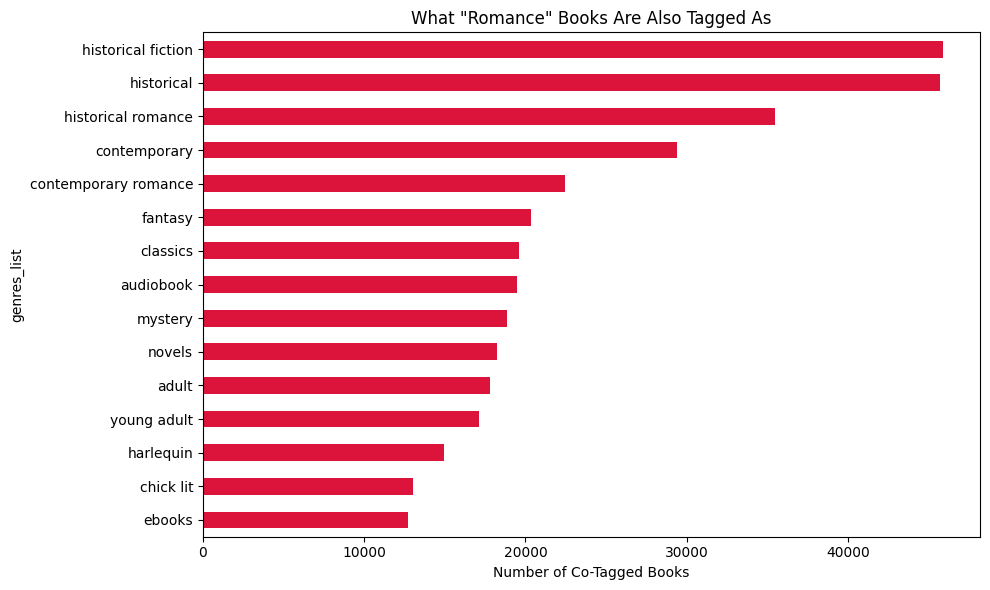

In [ ]:
co_tags_romance_top15 = co_tags_romance["genres_list"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6))
co_tags_romance_top15.sort_values().plot(kind="barh", ax=ax, color="crimson")
ax.set_xlabel("Number of Co-Tagged Books")
ax.set_title("What \"Romance\" Books Are Also Tagged As")
plt.tight_layout()
plt.show()